In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

print("First Five Rows")
print(df.head())

First Five Rows
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y               

In [4]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(32581, 12)


In [5]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None


In [6]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [8]:
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


In [9]:
df["loan_burden"] = df["loan_amnt"] / (df["person_income"] + 1)
df["employment_stability"] = (
    df["person_emp_length"] *
    df["cb_person_cred_hist_length"]
)
df["income_history_ratio"] = (
    df["person_income"] /
    (df["cb_person_cred_hist_length"] + 1)
)

df["interest_amount"] = (
    df["loan_amnt"] *
    df["loan_int_rate"] / 100
)

print("\nUpdated Dataset")
print(df.head())


Updated Dataset
   person_age  person_income  person_home_ownership  person_emp_length  \
0        22.0        59000.0                      3              123.0   
1        21.0         9600.0                      2                5.0   
2        25.0         9600.0                      0                1.0   
3        23.0        65500.0                      3                4.0   
4        24.0        54400.0                      3                8.0   

   loan_intent  loan_grade  loan_amnt  loan_int_rate  loan_status  \
0            4           3    35000.0          16.02          1.0   
1            1           1     1000.0          11.14          0.0   
2            3           2     5500.0          12.87          1.0   
3            3           2    35000.0          15.23          1.0   
4            3           2    35000.0          14.27          1.0   

   loan_percent_income  cb_person_default_on_file  cb_person_cred_hist_length  \
0                 0.59                    

In [10]:

X = df.drop("loan_status", axis=1)
y = df["loan_status"]


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

best_model = None
best_accuracy = 0

In [13]:
results = []


In [14]:
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Probability Prediction
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append((name, accuracy, precision, recall, f1, roc_auc))
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

print("\nBest Model:", best_model)
print("Best Accuracy:", best_accuracy)

/Users/sagunkumar/miniconda3/envs/biometric/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Best Model: RandomForestClassifier(random_state=42)
Best Accuracy: 0.9245051404020255


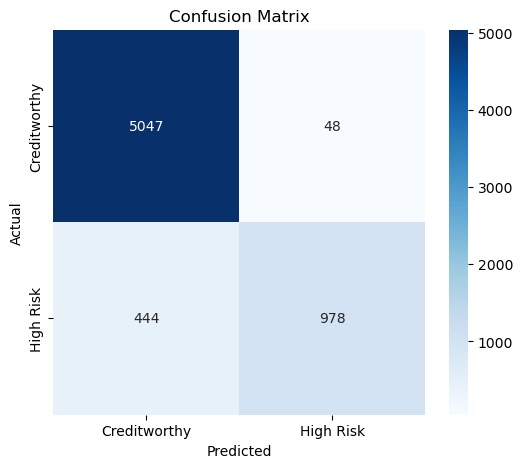

In [15]:


y_pred = best_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Creditworthy', 'High Risk'],
    yticklabels=['Creditworthy', 'High Risk']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



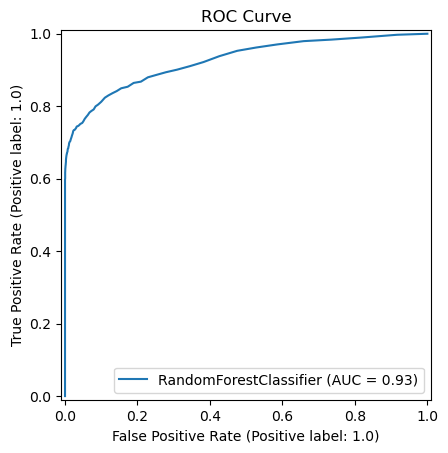

In [16]:

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [17]:
sample = pd.DataFrame({

    "person_age":[30],
    "person_income":[65000],
    "person_home_ownership":[1],
    "person_emp_length":[6],
    "loan_intent":[2],
    "loan_grade":[1],
    "loan_amnt":[12000],
    "loan_int_rate":[11.5],
    "loan_percent_income":[0.18],
    "cb_person_default_on_file":[0],
    "cb_person_cred_hist_length":[8],

    "loan_burden":[12000/65000],
    "employment_stability":[6*8],
    "income_history_ratio":[65000/(8+1)],
    "interest_amount":[12000*11.5/100]
})

prediction = best_model.predict(sample)

probability = best_model.predict_proba(sample)

In [18]:
if prediction[0] == 0:
    print("Applicant is CREDITWORTHY")
else:
    print("Applicant is HIGH CREDIT RISK")

print("Prediction Probability:")
print(probability)


Applicant is CREDITWORTHY
Prediction Probability:
[[0.93 0.07]]
